In [1468]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [1469]:
#muting all warnings
import warnings
warnings.filterwarnings('ignore')

In [1470]:
#import all files to be used...
historical_data=pd.read_csv('historical_sales.csv')
inventory_data=pd.read_csv('inventory_logs.csv')
shipment_data=pd.read_csv('shipments.csv')

In [1471]:
historical_data.head()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,stock_level_start,stock_level_end
0,2019-01-01,SKU0124,Fashion,Nairobi Warehouse,60,13204.21,757532.22,0,0,Supplier_O,106,NaN
1,2019-01-01,SKU0220,Beauty,Johannesburg DC,114,6603.03,766754.45,0,0,Supplier_P,126,NaN
2,2019-01-01,SKU0137,Home & Kitchen,Addis Ababa WH,40,14202.81,522499.21,0,0,Supplier_S,173,NaN
3,2019-01-01,SKU0078,Health,Accra Hub,130,7845.82,1129708.52,0,0,Supplier_N,328,NaN
4,2019-01-01,SKU0264,Groceries,Cairo Depot,86,3479.55,302428.82,1,0,Supplier_J,58,NaN


In [1472]:
historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131520 entries, 0 to 131519
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               131520 non-null  object 
 1   sku_id             131520 non-null  object 
 2   sku_category       131520 non-null  object 
 3   warehouse          131520 non-null  object 
 4   units_sold         131520 non-null  int64  
 5   unit_price_KES     131520 non-null  float64
 6   revenue_KES        131520 non-null  float64
 7   promotion_active   131520 non-null  int64  
 8   holiday_flag       131520 non-null  int64  
 9   supplier_id        131520 non-null  object 
 10  stock_level_start  131520 non-null  int64  
 11  stock_level_end    0 non-null       float64
dtypes: float64(3), int64(4), object(5)
memory usage: 12.0+ MB


In [1473]:
historical_data.describe()

,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,stock_level_start,stock_level_end
count,131520.000000,131520.000000,1.315200e+05,131520.000000,131520.000000,131520.000000,0.0
mean,114.551217,7800.401421,8.917132e+05,0.099932,0.032847,249.061588,NaN
std,190.828155,4343.755502,1.735579e+06,0.299910,0.178236,144.395435,NaN
min,0.000000,197.240000,0.000000e+00,0.000000,0.000000,0.000000,NaN
25%,63.000000,4117.105000,2.909098e+05,0.000000,0.000000,123.000000,NaN
50%,87.000000,7840.740000,6.231076e+05,0.000000,0.000000,248.000000,NaN
75%,118.000000,11418.807500,1.046845e+06,0.000000,0.000000,374.000000,NaN
max,5657.000000,16469.350000,6.313749e+07,1.000000,1.000000,500.000000,NaN


**From the historical_data; the `stock_level_end` has all missing values; other columns have no NaNs. Also from the `statistics of the data`, `there are definitely outliers`...**

In [1474]:
inventory_data.head()

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag
0,INV0000001,SKU0173,Nairobi Warehouse,2024-07-27,616,160,59,20,760,168,288,27.4,0
1,INV0000002,SKU0290,Nairobi Warehouse,2023-01-05,700,296,264,3,232,81,488,52.8,0
2,INV0000003,SKU0102,Lagos Facility,2019-05-22,685,384,40,16,527,162,189,NaN,0
3,INV0000004,SKU0045,Cairo Depot,2023-05-05,922,224,265,19,12,57,110,7.7,0
4,INV0000005,SKU0105,Cairo Depot,2021-03-28,310,203,9,3,759,95,451,13.2,0


In [1475]:
inventory_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   log_id         40000 non-null  object 
 1   sku_id         40000 non-null  object 
 2   warehouse      40000 non-null  object 
 3   snapshot_date  40000 non-null  object 
 4   opening_stock  40000 non-null  int64  
 5   received_qty   40000 non-null  int64  
 6   sold_qty       40000 non-null  int64  
 7   damaged_qty    40000 non-null  int64  
 8   closing_stock  40000 non-null  int64  
 9   reorder_point  40000 non-null  int64  
 10  reorder_qty    40000 non-null  int64  
 11  days_of_stock  37209 non-null  float64
 12  stockout_flag  40000 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 4.0+ MB


In [1476]:
inventory_data.describe()

,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag
count,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,37209.000000,40000.000000
mean,501.047050,250.760850,149.740375,9.98580,397.265625,125.365275,299.329475,29.886702,0.048525
std,289.730107,144.462402,87.227969,6.05167,230.974976,43.553029,115.338108,17.357155,0.214875
min,0.000000,0.000000,0.000000,0.00000,0.000000,50.000000,100.000000,0.000000,0.000000
25%,249.000000,126.000000,74.000000,5.00000,197.000000,88.000000,199.000000,14.800000,0.000000
50%,503.000000,251.000000,150.000000,10.00000,396.000000,126.000000,300.000000,29.700000,0.000000
75%,753.000000,375.000000,226.000000,15.00000,597.000000,163.000000,399.000000,44.900000,0.000000
max,1000.000000,500.000000,300.000000,20.00000,800.000000,200.000000,500.000000,60.000000,1.000000


In [1477]:
inventory_data.isnull().sum()

log_id              0
sku_id              0
warehouse           0
snapshot_date       0
opening_stock       0
received_qty        0
sold_qty            0
damaged_qty         0
closing_stock       0
reorder_point       0
reorder_qty         0
days_of_stock    2791
stockout_flag       0
dtype: int64

**`days_of_stock` has missing values, the other columns have no NaNs; needs to be recomputed`stock_level_end / average_daily_demand(from forecasting model)`**

**Using this `inventory_data['received_qty']` as part of computation when `filling` in the `NaNs` in `historical_data`**

In [1478]:
#creating new copy of the files...

inventory_copy=inventory_data.copy()
historical_copy=historical_data.copy()
shipment_copy=shipment_data.copy()

In [1479]:
#preparing data for mapping....

historical_copy['warehouse']=historical_copy['warehouse'].str.replace(' ', '_')
inventory_copy['warehouse']=inventory_copy['warehouse'].str.replace(' ', '_')

historical_copy['skuId_warehouse_date']=historical_copy['date'] + '_' +  historical_copy['sku_id'] +  '_' + historical_copy['warehouse']
inventory_copy['skuId_warehouse_date']=inventory_copy['snapshot_date'] + '_' +  inventory_copy['sku_id'] + '_'  + inventory_copy['warehouse'] 

In [1480]:
#merging the 1 column 'received_qty'  to everything matching the unique col skuId_warehouse_date on historical data
historical_copy=pd.merge(historical_copy,inventory_copy[['skuId_warehouse_date','received_qty']], on=['skuId_warehouse_date'],how='inner')

In [1481]:
historical_copy.head()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,stock_level_start,stock_level_end,skuId_warehouse_date,received_qty
0,2019-01-01,SKU0083,Toys,Accra_Hub,78,5436.63,430363.19,0,0,Supplier_J,240,NaN,2019-01-01_SKU0083_Accra_Hub,102
1,2019-01-02,SKU0145,Health,Cairo_Depot,49,6262.10,306717.59,0,0,Supplier_H,73,NaN,2019-01-02_SKU0145_Cairo_Depot,45
2,2019-01-02,SKU0057,Automotive,Cairo_Depot,40,13929.74,521355.02,0,0,Supplier_F,236,NaN,2019-01-02_SKU0057_Cairo_Depot,226
3,2019-01-05,SKU0018,Books,Accra_Hub,55,4243.72,219032.35,0,0,Supplier_B,319,NaN,2019-01-05_SKU0018_Accra_Hub,409
4,2019-01-06,SKU0188,Books,Addis_Ababa_WH,73,1023.81,74402.07,0,0,Supplier_K,479,NaN,2019-01-06_SKU0188_Addis_Ababa_WH,132


In [1482]:
#computing the new stock_level_end columns based on [stock_level_start -units_sold + received_qty] logic
historical_copy['stock_level_end']=historical_copy['stock_level_start'] - historical_copy['units_sold'] + historical_copy['received_qty']

In [1483]:
historical_copy.head()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,stock_level_start,stock_level_end,skuId_warehouse_date,received_qty
0,2019-01-01,SKU0083,Toys,Accra_Hub,78,5436.63,430363.19,0,0,Supplier_J,240,264,2019-01-01_SKU0083_Accra_Hub,102
1,2019-01-02,SKU0145,Health,Cairo_Depot,49,6262.10,306717.59,0,0,Supplier_H,73,69,2019-01-02_SKU0145_Cairo_Depot,45
2,2019-01-02,SKU0057,Automotive,Cairo_Depot,40,13929.74,521355.02,0,0,Supplier_F,236,422,2019-01-02_SKU0057_Cairo_Depot,226
3,2019-01-05,SKU0018,Books,Accra_Hub,55,4243.72,219032.35,0,0,Supplier_B,319,673,2019-01-05_SKU0018_Accra_Hub,409
4,2019-01-06,SKU0188,Books,Addis_Ababa_WH,73,1023.81,74402.07,0,0,Supplier_K,479,538,2019-01-06_SKU0188_Addis_Ababa_WH,132


In [1484]:
historical_copy.isnull().sum()

date                    0
sku_id                  0
sku_category            0
warehouse               0
units_sold              0
unit_price_KES          0
revenue_KES             0
promotion_active        0
holiday_flag            0
supplier_id             0
stock_level_start       0
stock_level_end         0
skuId_warehouse_date    0
received_qty            0
dtype: int64

**Worked on `NaN` inside the `historical data`. Proceeding to handling outliers....**

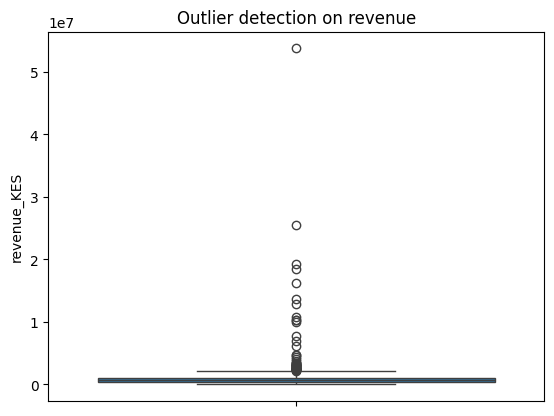

In [1485]:
plt.title('Outlier detection on revenue')
sns.boxplot(historical_copy['revenue_KES'])
plt.show()

In [1486]:
historical_copy['revenue_KES'].describe()

count    1.337000e+03
mean     9.142852e+05
std      2.044366e+06
min      0.000000e+00
25%      3.086742e+05
50%      6.377580e+05
75%      1.050455e+06
max      5.375517e+07
Name: revenue_KES, dtype: float64

In [1487]:
Q1=np.quantile(historical_copy['revenue_KES'],q=0.25)
Q3=np.quantile(historical_copy['revenue_KES'],q=0.75)
IQR=Q3-Q1
print('Q1:',Q1,'Q3:',Q3, 'IQR:',IQR)

Q1: 308674.21 Q3: 1050455.38 IQR: 741781.1699999999


In [1488]:
Q3 + 3 * IQR

np.float64(3275798.8899999997)

In [1489]:
Q3 + 1.5 * IQR

np.float64(2163127.135)

In [1490]:
outliers=[]
revenue_KES=[]
for i in historical_copy['revenue_KES']:
    if i > Q3 + 1.5 * IQR:
        outliers.append(i)

In [1491]:
len(outliers)

50

**There are 50 outlier values using this condition: `MAX_REVENUE=Q3 + 1.5 * IQR`**

In [1492]:
MAX_REVENUE=Q3 + 1.5 * IQR

In [1493]:
historical_copy['revenue_KES']=np.where(historical_copy['revenue_KES']> MAX_REVENUE,MAX_REVENUE,historical_copy['revenue_KES'])

In [1494]:
historical_copy['revenue_KES'].describe()

count    1.337000e+03
mean     7.505969e+05
std      5.557313e+05
min      0.000000e+00
25%      3.086742e+05
50%      6.377580e+05
75%      1.050455e+06
max      2.163127e+06
Name: revenue_KES, dtype: float64

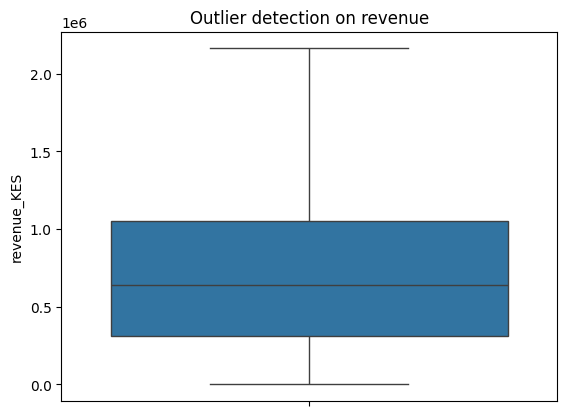

In [1495]:
plt.title('Outlier detection on revenue')
sns.boxplot(historical_copy['revenue_KES'])
plt.show()

In [1496]:
historical_copy.head()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,stock_level_start,stock_level_end,skuId_warehouse_date,received_qty
0,2019-01-01,SKU0083,Toys,Accra_Hub,78,5436.63,430363.19,0,0,Supplier_J,240,264,2019-01-01_SKU0083_Accra_Hub,102
1,2019-01-02,SKU0145,Health,Cairo_Depot,49,6262.10,306717.59,0,0,Supplier_H,73,69,2019-01-02_SKU0145_Cairo_Depot,45
2,2019-01-02,SKU0057,Automotive,Cairo_Depot,40,13929.74,521355.02,0,0,Supplier_F,236,422,2019-01-02_SKU0057_Cairo_Depot,226
3,2019-01-05,SKU0018,Books,Accra_Hub,55,4243.72,219032.35,0,0,Supplier_B,319,673,2019-01-05_SKU0018_Accra_Hub,409
4,2019-01-06,SKU0188,Books,Addis_Ababa_WH,73,1023.81,74402.07,0,0,Supplier_K,479,538,2019-01-06_SKU0188_Addis_Ababa_WH,132


In [1497]:
#adjusting units sold for the calculations to be accurate
historical_copy['units_sold']=(historical_copy['revenue_KES'] / historical_copy['unit_price_KES']).truncate() #truncate trailing decimal values...
historical_copy['units_sold']=historical_copy['units_sold'].astype(int)

#Ensuring units_sold * unit_price_KES= revenue_KES; after rounding units_sold
historical_copy['revenue_KES']=(historical_copy['units_sold'] * historical_copy['unit_price_KES'])

In [1498]:
historical_copy.head()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,stock_level_start,stock_level_end,skuId_warehouse_date,received_qty
0,2019-01-01,SKU0083,Toys,Accra_Hub,79,5436.63,429493.77,0,0,Supplier_J,240,264,2019-01-01_SKU0083_Accra_Hub,102
1,2019-01-02,SKU0145,Health,Cairo_Depot,48,6262.10,300580.80,0,0,Supplier_H,73,69,2019-01-02_SKU0145_Cairo_Depot,45
2,2019-01-02,SKU0057,Automotive,Cairo_Depot,37,13929.74,515400.38,0,0,Supplier_F,236,422,2019-01-02_SKU0057_Cairo_Depot,226
3,2019-01-05,SKU0018,Books,Accra_Hub,51,4243.72,216429.72,0,0,Supplier_B,319,673,2019-01-05_SKU0018_Accra_Hub,409
4,2019-01-06,SKU0188,Books,Addis_Ababa_WH,72,1023.81,73714.32,0,0,Supplier_K,479,538,2019-01-06_SKU0188_Addis_Ababa_WH,132


In [1499]:
historical_copy['sku_id'].value_counts()

sku_id
SKU0069    11
SKU0228    11
SKU0239    10
SKU0134    10
SKU0145    10
           ..
SKU0126     1
SKU0031     1
SKU0055     1
SKU0227     1
SKU0093     1
Name: count, Length: 295, dtype: int64

**Time-series frequency alignment**

In [1500]:
historical_warehouse_agg_day=historical_copy.groupby(['date','warehouse']).agg({'units_sold': 'sum', 'revenue_KES': 'sum'}).reset_index()

In [1501]:
historical_warehouse_agg_day

,date,warehouse,units_sold,revenue_KES
0,2019-01-01,Accra_Hub,79,429493.77
1,2019-01-02,Cairo_Depot,85,815981.18
2,2019-01-05,Accra_Hub,51,216429.72
3,2019-01-06,Addis_Ababa_WH,72,73714.32
4,2019-01-07,Cairo_Depot,36,500384.52
...,...,...,...,...
1250,2024-12-19,Johannesburg_DC,156,486985.20
1251,2024-12-22,Nairobi_Warehouse,51,656912.13
1252,2024-12-24,Johannesburg_DC,193,545371.68
1253,2024-12-26,Johannesburg_DC,801,2162107.26


**Working on Inventory_data...**

In [1502]:
inventory_copy.head()

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,skuId_warehouse_date
0,INV0000001,SKU0173,Nairobi_Warehouse,2024-07-27,616,160,59,20,760,168,288,27.4,0,2024-07-27_SKU0173_Nairobi_Warehouse
1,INV0000002,SKU0290,Nairobi_Warehouse,2023-01-05,700,296,264,3,232,81,488,52.8,0,2023-01-05_SKU0290_Nairobi_Warehouse
2,INV0000003,SKU0102,Lagos_Facility,2019-05-22,685,384,40,16,527,162,189,NaN,0,2019-05-22_SKU0102_Lagos_Facility
3,INV0000004,SKU0045,Cairo_Depot,2023-05-05,922,224,265,19,12,57,110,7.7,0,2023-05-05_SKU0045_Cairo_Depot
4,INV0000005,SKU0105,Cairo_Depot,2021-03-28,310,203,9,3,759,95,451,13.2,0,2021-03-28_SKU0105_Cairo_Depot


**Work on closing_stock column**

In [1503]:
# flagging if days_of_stock aint equal to [opening_stock+received_qty-sold-damaged_qty]
inventory_copy['closing_stock_missmatch_flag']=np.where(inventory_copy['closing_stock'] != (inventory_copy['opening_stock'] + inventory_copy['received_qty'] -inventory_copy['sold_qty'] - inventory_copy['damaged_qty']),1,0 )

In [1504]:
inventory_copy['closing_stock_missmatch_flag'].value_counts()

closing_stock_missmatch_flag
1    39971
0       29
Name: count, dtype: int64

In [1505]:
inventory_copy[inventory_copy['closing_stock_missmatch_flag']==0].head()

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,skuId_warehouse_date,closing_stock_missmatch_flag
1862,INV0001863,SKU0187,Cairo_Depot,2023-02-26,754,216,251,9,710,200,412,52.8,0,2023-02-26_SKU0187_Cairo_Depot,0
3028,INV0003029,SKU0094,Johannesburg_DC,2020-06-21,124,247,204,13,154,189,389,9.9,0,2020-06-21_SKU0094_Johannesburg_DC,0
4895,INV0004896,SKU0152,Johannesburg_DC,2022-03-13,154,118,15,14,243,164,213,12.0,0,2022-03-13_SKU0152_Johannesburg_DC,0
7979,INV0007980,SKU0150,Addis_Ababa_WH,2023-06-16,324,18,260,4,78,53,217,49.9,0,2023-06-16_SKU0150_Addis_Ababa_WH,0
8860,INV0008861,SKU0167,Johannesburg_DC,2024-10-28,189,103,24,0,268,176,404,36.2,0,2024-10-28_SKU0167_Johannesburg_DC,0


**They are only 29 records that are logically  correct for the `closing_stock` column...Recomputing it again:**

In [1506]:
inventory_copy['closing_stock']=inventory_copy['opening_stock'] + inventory_copy['received_qty'] - inventory_copy['sold_qty'] - inventory_copy['damaged_qty']

In [1507]:
inventory_copy[inventory_copy['closing_stock_missmatch_flag']==1].sample(3)

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,skuId_warehouse_date,closing_stock_missmatch_flag
33615,INV0033616,SKU0124,Johannesburg_DC,2022-03-18,300,52,298,12,42,160,324,59.7,0,2022-03-18_SKU0124_Johannesburg_DC,1
33382,INV0033383,SKU0062,Accra_Hub,2024-03-19,137,39,25,3,148,79,365,5.8,0,2024-03-19_SKU0062_Accra_Hub,1
39919,INV0039920,SKU0218,Johannesburg_DC,2024-06-18,212,296,94,19,395,146,114,38.0,0,2024-06-18_SKU0218_Johannesburg_DC,1


**Working on shipment data...**

In [1508]:
shipment_copy.head()

,shipment_id,supplier_id,sku_id,warehouse,ship_date,expected_delivery,actual_delivery,quantity_shipped,quantity_received,damage_reported,carrier,delay_days,delay_reason
0,SHP0000001,Supplier_N,SKU0101,Cairo Depot,2020-11-03,2020-11-15,2020-11-17,1467,610,0,G4S Logistics,2,NaN
1,SHP0000002,Supplier_S,SKU0078,Addis Ababa WH,2019-10-28,2019-11-10,2019-11-11,660,781,0,Kenya Courier,1,Vehicle breakdown
2,SHP0000003,Supplier_P,SKU0255,Lagos Facility,2024-01-21,2024-01-25,2024-02-01,1610,862,0,FedEx,7,NaN
3,SHP0000004,Supplier_C,SKU0018,Cairo Depot,2021-06-01,2021-06-05,2021-06-10,1726,1703,0,Kenya Courier,5,Customs
4,SHP0000005,Supplier_M,SKU0188,Nairobi Warehouse,2021-02-10,2021-02-24,NaN,97,1222,0,FedEx,3,Customs


**flagging extreme delay_days**

In [1509]:
shipment_copy['delay_days'].median()

np.float64(4.0)

In [1510]:
shipment_copy['extreme_delay_days']=np.where(shipment_copy['delay_days'] > (2*shipment_copy['delay_days'].median()),1,0 )

In [1511]:
len( shipment_copy[shipment_copy['extreme_delay_days'] ==1] )

3837

**There are 3837 records whose delay_days are > 8 days**

In [1512]:
shipment_copy.isnull().sum()

shipment_id               0
supplier_id               0
sku_id                    0
warehouse                 0
ship_date                 0
expected_delivery         0
actual_delivery        2055
quantity_shipped          0
quantity_received         0
damage_reported           0
carrier                   0
delay_days                0
delay_reason          11040
extreme_delay_days        0
dtype: int64

In [1513]:
shipment_copy['actual_delivery']=shipment_copy['actual_delivery'].fillna('Unkown')
shipment_copy['delay_reason']=shipment_copy['delay_reason'].fillna('Unkown')

In [1514]:
shipment_copy.isnull().sum()

shipment_id           0
supplier_id           0
sku_id                0
warehouse             0
ship_date             0
expected_delivery     0
actual_delivery       0
quantity_shipped      0
quantity_received     0
damage_reported       0
carrier               0
delay_days            0
delay_reason          0
extreme_delay_days    0
dtype: int64

**Feature Engineering**

In [1515]:
historical_copy.head()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,stock_level_start,stock_level_end,skuId_warehouse_date,received_qty
0,2019-01-01,SKU0083,Toys,Accra_Hub,79,5436.63,429493.77,0,0,Supplier_J,240,264,2019-01-01_SKU0083_Accra_Hub,102
1,2019-01-02,SKU0145,Health,Cairo_Depot,48,6262.10,300580.80,0,0,Supplier_H,73,69,2019-01-02_SKU0145_Cairo_Depot,45
2,2019-01-02,SKU0057,Automotive,Cairo_Depot,37,13929.74,515400.38,0,0,Supplier_F,236,422,2019-01-02_SKU0057_Cairo_Depot,226
3,2019-01-05,SKU0018,Books,Accra_Hub,51,4243.72,216429.72,0,0,Supplier_B,319,673,2019-01-05_SKU0018_Accra_Hub,409
4,2019-01-06,SKU0188,Books,Addis_Ababa_WH,72,1023.81,73714.32,0,0,Supplier_K,479,538,2019-01-06_SKU0188_Addis_Ababa_WH,132


In [1516]:
historical_copy['date']=pd.to_datetime(historical_copy['date'])

In [1517]:
historical_copy['quarter_date']=historical_copy['date'].dt.quarter
historical_copy['month_date']=historical_copy['date'].dt.month
historical_copy['day_date']=historical_copy['date'].dt.day_name()
historical_copy['week']=historical_copy['date'].dt.isocalendar().week
historical_copy['weekday']=historical_copy['date'].dt.weekday
historical_copy['is_weekend']=np.where(historical_copy['weekday']>=5,1,0)

In [1518]:
historical_copy.head(7)

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,stock_level_start,stock_level_end,skuId_warehouse_date,received_qty,quarter_date,month_date,day_date,week,weekday,is_weekend
0,2019-01-01,SKU0083,Toys,Accra_Hub,79,5436.63,429493.77,0,0,Supplier_J,240,264,2019-01-01_SKU0083_Accra_Hub,102,1,1,Tuesday,1,1,0
1,2019-01-02,SKU0145,Health,Cairo_Depot,48,6262.10,300580.80,0,0,Supplier_H,73,69,2019-01-02_SKU0145_Cairo_Depot,45,1,1,Wednesday,1,2,0
2,2019-01-02,SKU0057,Automotive,Cairo_Depot,37,13929.74,515400.38,0,0,Supplier_F,236,422,2019-01-02_SKU0057_Cairo_Depot,226,1,1,Wednesday,1,2,0
3,2019-01-05,SKU0018,Books,Accra_Hub,51,4243.72,216429.72,0,0,Supplier_B,319,673,2019-01-05_SKU0018_Accra_Hub,409,1,1,Saturday,1,5,1
4,2019-01-06,SKU0188,Books,Addis_Ababa_WH,72,1023.81,73714.32,0,0,Supplier_K,479,538,2019-01-06_SKU0188_Addis_Ababa_WH,132,1,1,Sunday,1,6,1
5,2019-01-07,SKU0195,Automotive,Cairo_Depot,36,13899.57,500384.52,0,0,Supplier_M,359,701,2019-01-07_SKU0195_Cairo_Depot,378,1,1,Monday,2,0,0
6,2019-01-18,SKU0177,Sports,Accra_Hub,395,4560.32,1801326.40,0,0,Supplier_E,163,56,2019-01-18_SKU0177_Accra_Hub,289,1,1,Friday,3,4,0


In [1519]:
historical_copy['7_day_rolling_mean_units_sold']= historical_copy['units_sold'].rolling(7).mean()
historical_copy['30_day_rolling_mean_units_sold']= historical_copy['units_sold'].rolling(30).mean() 
historical_copy['90_day_rolling_mean_units_sold']= historical_copy['units_sold'].rolling(90).mean()

historical_copy['7_day_rolling_mean_units_sold']=round(historical_copy['7_day_rolling_mean_units_sold'], 0)
historical_copy['30_day_rolling_mean_units_sold']=round(historical_copy['30_day_rolling_mean_units_sold'],0)
historical_copy['90_day_rolling_mean_units_sold']=round(historical_copy['90_day_rolling_mean_units_sold'], 0)

In [1520]:
historical_copy.tail()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,...,received_qty,quarter_date,month_date,day_date,week,weekday,is_weekend,7_day_rolling_mean_units_sold,30_day_rolling_mean_units_sold,90_day_rolling_mean_units_sold
1332,2024-12-19,SKU0228,Health,Johannesburg_DC,156,3121.70,486985.20,0,0,Supplier_F,...,147,4,12,Thursday,51,3,0,153.0,143.0,113.0
1333,2024-12-22,SKU0048,Health,Nairobi_Warehouse,51,12880.63,656912.13,0,1,Supplier_M,...,211,4,12,Sunday,51,6,1,139.0,142.0,112.0
1334,2024-12-24,SKU0213,Toys,Johannesburg_DC,193,2825.76,545371.68,0,1,Supplier_Q,...,72,4,12,Tuesday,52,1,0,148.0,147.0,111.0
1335,2024-12-26,SKU0152,Home & Kitchen,Johannesburg_DC,801,2699.26,2162107.26,0,1,Supplier_P,...,276,4,12,Thursday,52,3,0,247.0,168.0,118.0
1336,2024-12-27,SKU0184,Fashion,Lagos_Facility,28,7229.37,202422.36,0,1,Supplier_L,...,420,4,12,Friday,52,4,0,221.0,162.0,117.0


In [1521]:
historical_copy['date'].min(), historical_copy['date'].median(),historical_copy['date'].max()

(Timestamp('2019-01-01 00:00:00'),
 Timestamp('2021-12-31 00:00:00'),
 Timestamp('2024-12-27 00:00:00'))

In [1522]:
units_sold_data=historical_copy[['date','units_sold','promotion_active','holiday_flag','is_weekend']]

In [1523]:
units_sold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1337 non-null   datetime64[ns]
 1   units_sold        1337 non-null   int64         
 2   promotion_active  1337 non-null   int64         
 3   holiday_flag      1337 non-null   int64         
 4   is_weekend        1337 non-null   int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 52.4 KB


In [1524]:
units_sold_data.head()

,date,units_sold,promotion_active,holiday_flag,is_weekend
0,2019-01-01,79,0,0,0
1,2019-01-02,48,0,0,0
2,2019-01-02,37,0,0,0
3,2019-01-05,51,0,0,1
4,2019-01-06,72,0,0,1


In [1525]:
# there needs resampling since some days have no units_sold...
units_sold_data=units_sold_data.set_index('date').resample('ME').agg({'units_sold': 'sum'})
units_sold_data=units_sold_data.fillna(0)

In [1526]:
len(units_sold_data)

72

**ARIMA FORECASTING `Units_sold`...**

In [1527]:
from statsmodels.tsa.arima.model import ARIMA

In [1528]:
units_model=ARIMA(units_sold_data['units_sold'], order=(1,1,1) )

units_model_fit=units_model.fit()

# forecasting future 2 years
units_forecast=units_model_fit.forecast(steps=24)

print(units_sold_data.index[-1])

#creating future index dates..
future_dates=pd.date_range(start=units_sold_data.index[-1],periods=24,freq='ME')
units_forecast

2024-12-31 00:00:00


2025-01-31    2069.323185
2025-02-28    1860.005291
2025-03-31    1822.482939
2025-04-30    1815.756677
2025-05-31    1814.550927
2025-06-30    1814.334784
2025-07-31    1814.296038
2025-08-31    1814.289093
2025-09-30    1814.287847
2025-10-31    1814.287624
2025-11-30    1814.287584
2025-12-31    1814.287577
2026-01-31    1814.287576
2026-02-28    1814.287576
2026-03-31    1814.287576
2026-04-30    1814.287576
2026-05-31    1814.287576
2026-06-30    1814.287576
2026-07-31    1814.287576
2026-08-31    1814.287576
2026-09-30    1814.287576
2026-10-31    1814.287576
2026-11-30    1814.287576
2026-12-31    1814.287576
Freq: ME, Name: predicted_mean, dtype: float64

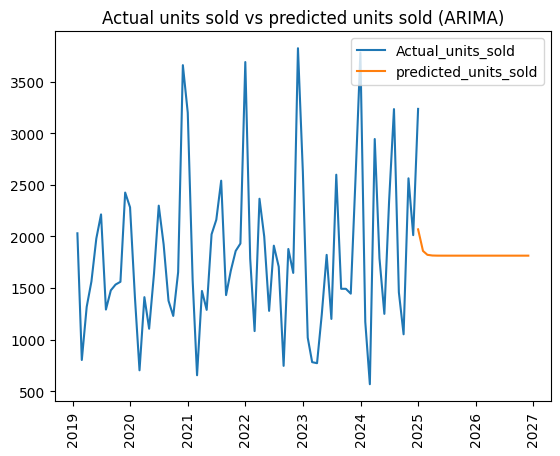

In [1529]:
plt.title('Actual units sold vs predicted units sold (ARIMA)')
plt.plot(units_sold_data.index,units_sold_data['units_sold'],label='Actual_units_sold')
plt.plot(future_dates,units_forecast.values,label='predicted_units_sold')
plt.xticks(rotation=90)
plt.legend()
plt.show()

**ARIMA IS UNABLE TO IDENTIFY THE TRENDS...SWITCHING TO `pmdarima`..to indendify seasonality...**

In [1530]:
from pmdarima import auto_arima

In [1531]:
%%time
model=auto_arima(units_sold_data['units_sold'],seasonal=True,m=12)
predictions_units=model.predict(n_periods=24)
predictions_units

CPU times: user 2min 44s, sys: 136 ms, total: 2min 44s
Wall time: 22.9 s


2025-01-31    1749.371412
2025-02-28     756.963955
2025-03-31    2010.657716
2025-04-30    1596.929023
2025-05-31    1501.865664
2025-06-30    2059.633580
2025-07-31    2183.541234
2025-08-31    1850.288808
2025-09-30    1421.042508
2025-10-31    1821.184705
2025-11-30    2363.114971
2025-12-31    2643.438816
2026-01-31    1813.690122
2026-02-28     982.675921
2026-03-31    2246.551403
2026-04-30    1910.901625
2026-05-31    1324.516314
2026-06-30    2288.968583
2026-07-31    2293.851672
2026-08-31    1730.558124
2026-09-30    1549.137494
2026-10-31    1919.060265
2026-11-30    2235.839370
2026-12-31    2419.507283
Freq: ME, dtype: float64

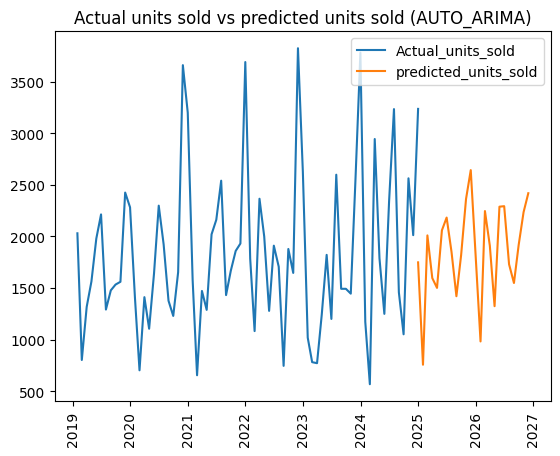

In [1532]:
plt.title('Actual units sold vs predicted units sold (AUTO_ARIMA)')
plt.plot(units_sold_data.index,units_sold_data['units_sold'],label='Actual_units_sold')
plt.plot(future_dates,predictions_units.values,label='predicted_units_sold')
plt.xticks(rotation=90)
plt.legend()
plt.show()

**Using Prophet model**

In [1533]:
from prophet import Prophet

In [1534]:
units_sold_data=units_sold_data.reset_index()

In [1535]:
units_sold_data.columns=['ds','y']

In [1536]:
units_prophet_model=Prophet(yearly_seasonality=True,interval_width=0.95) #setting the model to have seasonality effect and uncertainity intervals of 95%('confidence level')

In [1537]:
units_prophet_model.fit(units_sold_data)

15:29:12 - cmdstanpy - INFO - Chain [1] start processing
15:29:12 - cmdstanpy - INFO - Chain [1] done processing


In [1538]:
#creating future dates
future_units_data=units_prophet_model.make_future_dataframe(periods=24,freq='ME')

In [1539]:
#forecasting
units_prophet_forecast=units_prophet_model.predict(future_units_data)

In [1540]:
#selecting the needed columns after forecasting...
units_prophet_forecast_results=units_prophet_forecast[['ds','yhat_lower','yhat','yhat_upper']]

In [1541]:
units_prophet_forecast_results

,ds,yhat_lower,yhat,yhat_upper
0,2019-01-31,678.807236,1418.298101,2306.289871
1,2019-02-28,64.817212,924.266477,1710.560589
2,2019-03-31,541.309393,1295.037514,2047.013020
3,2019-04-30,775.397870,1581.658279,2423.445361
4,2019-05-31,1081.121925,1866.144781,2699.277441
...,...,...,...,...
91,2026-08-31,689.492026,1486.592391,2340.684712
92,2026-09-30,902.235421,1706.614640,2589.368358
93,2026-10-31,1016.190971,1852.078990,2709.402591
94,2026-11-30,2051.972227,2894.749434,3708.036928


In [1542]:
#renaming the columns
units_prophet_forecast_results=units_prophet_forecast_results.rename(columns={'ds':'date','yhat_lower': 'lower_bond','yhat': 'units_sold','yhat_upper':'upper_bond'})

In [1543]:
units_prophet_forecast_results.to_csv('units_prophet_forecast_results.csv')

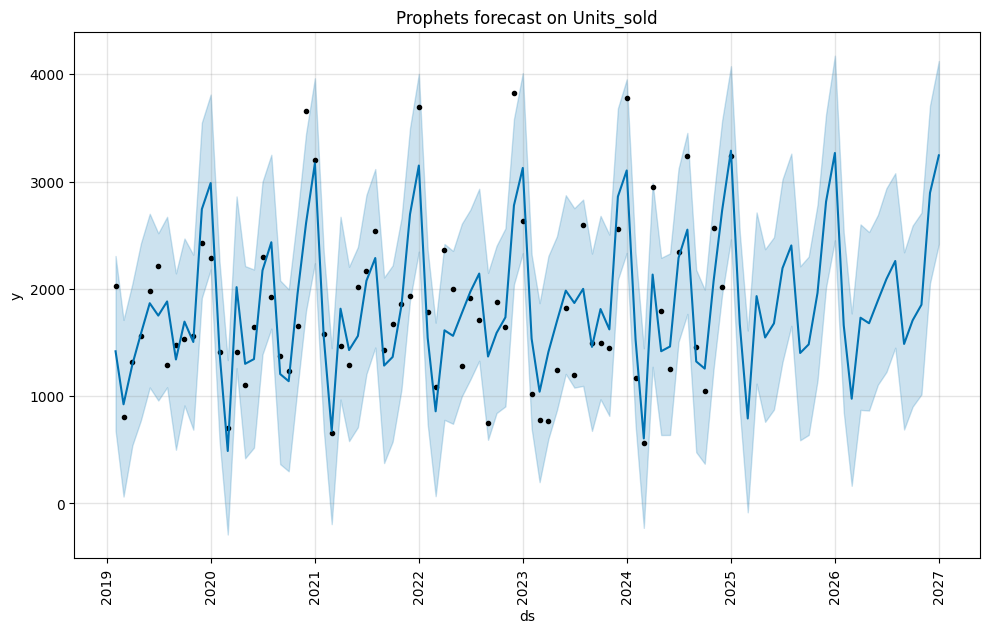

In [1544]:
#visualizing the dataframe
units_prophet_model.plot(units_prophet_forecast)
plt.xticks(rotation=90)
plt.title('Prophets forecast on Units_sold')
plt.show()

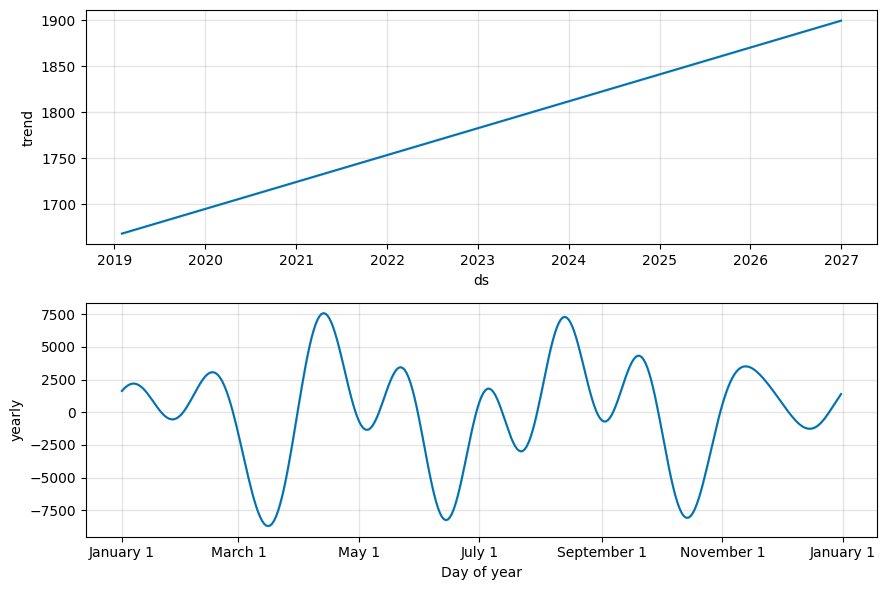

In [1545]:
#visualizing the components of the model...
units_prophet_model.plot_components(units_prophet_forecast)
plt.show()

**The above are the forecasted units to be sold per month..proceeding to units predictions per sku-unit-warehouse...**

In [1546]:
historical_copy.tail()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,...,received_qty,quarter_date,month_date,day_date,week,weekday,is_weekend,7_day_rolling_mean_units_sold,30_day_rolling_mean_units_sold,90_day_rolling_mean_units_sold
1332,2024-12-19,SKU0228,Health,Johannesburg_DC,156,3121.70,486985.20,0,0,Supplier_F,...,147,4,12,Thursday,51,3,0,153.0,143.0,113.0
1333,2024-12-22,SKU0048,Health,Nairobi_Warehouse,51,12880.63,656912.13,0,1,Supplier_M,...,211,4,12,Sunday,51,6,1,139.0,142.0,112.0
1334,2024-12-24,SKU0213,Toys,Johannesburg_DC,193,2825.76,545371.68,0,1,Supplier_Q,...,72,4,12,Tuesday,52,1,0,148.0,147.0,111.0
1335,2024-12-26,SKU0152,Home & Kitchen,Johannesburg_DC,801,2699.26,2162107.26,0,1,Supplier_P,...,276,4,12,Thursday,52,3,0,247.0,168.0,118.0
1336,2024-12-27,SKU0184,Fashion,Lagos_Facility,28,7229.37,202422.36,0,1,Supplier_L,...,420,4,12,Friday,52,4,0,221.0,162.0,117.0


In [1547]:
historical_copy['sku_warehouse']=historical_copy['sku_id']+ '_' + historical_copy['warehouse']

In [1548]:
historical_copy['sku_warehouse'].nunique()

945

In [1549]:
len(historical_copy)

1337

In [1550]:
sku_warehouse_agg=historical_copy.groupby(['date','sku_warehouse']).agg( {'units_sold': 'sum'} ).reset_index()
sku_warehouse_agg=sku_warehouse_agg.set_index('date')

#aggregating by monthly_data for sku_warehouse--units_sold
sku_warehouse_agg=sku_warehouse_agg.groupby('sku_warehouse').resample('ME').agg({'units_sold': 'sum' }).reset_index().sort_values('date')

In [1551]:
sku_warehouse_agg

,sku_warehouse,date,units_sold
6985,SKU0233_Addis_Ababa_WH,2019-01-31,88
5831,SKU0195_Cairo_Depot,2019-01-31,36
2523,SKU0097_Johannesburg_DC,2019-01-31,62
1380,SKU0041_Johannesburg_DC,2019-01-31,895
1730,SKU0057_Cairo_Depot,2019-01-31,37
...,...,...,...
4111,SKU0152_Johannesburg_DC,2024-12-31,801
1575,SKU0047_Nairobi_Warehouse,2024-12-31,122
4957,SKU0178_Addis_Ababa_WH,2024-12-31,147
1961,SKU0069_Accra_Hub,2024-12-31,126


**Aggregating total_units sold each day**

In [1552]:
total_units_sold_day_agg=historical_copy.groupby('date').agg({'units_sold':'sum'}).reset_index()
total_units_sold_day_agg=total_units_sold_day_agg.set_index('date')

#aggregating total_units_sold per month for each year in the data...
total_units_sold_day_agg=total_units_sold_day_agg.resample('ME').agg({'units_sold': 'sum'}).reset_index().sort_values('date')
total_units_sold_day_agg=total_units_sold_day_agg.set_index('date')

In [1553]:
total_units_sold_day_agg

,units_sold
date,
2019-01-31,2031
2019-02-28,803
2019-03-31,1318
2019-04-30,1564
2019-05-31,1980
...,...
2024-08-31,1459
2024-09-30,1052
2024-10-31,2564


In [1554]:
#merging the two dataframes...
sku_warehouse_agg['total_units_sold_monthly']=sku_warehouse_agg['date'].map(total_units_sold_day_agg['units_sold'])

In [1555]:
sku_warehouse_agg

,sku_warehouse,date,units_sold,total_units_sold_monthly
6985,SKU0233_Addis_Ababa_WH,2019-01-31,88,2031
5831,SKU0195_Cairo_Depot,2019-01-31,36,2031
2523,SKU0097_Johannesburg_DC,2019-01-31,62,2031
1380,SKU0041_Johannesburg_DC,2019-01-31,895,2031
1730,SKU0057_Cairo_Depot,2019-01-31,37,2031
...,...,...,...,...
4111,SKU0152_Johannesburg_DC,2024-12-31,801,3237
1575,SKU0047_Nairobi_Warehouse,2024-12-31,122,3237
4957,SKU0178_Addis_Ababa_WH,2024-12-31,147,3237
1961,SKU0069_Accra_Hub,2024-12-31,126,3237


**Calculating the proportion of units_sold per `sku_warehouse` to `total_units_sold_monthly`**

In [1556]:
sku_warehouse_agg['ratio_units_sold_totals_month']=sku_warehouse_agg['units_sold'] / sku_warehouse_agg['total_units_sold_monthly']

In [1557]:
sku_warehouse_agg=sku_warehouse_agg.sort_values(by=['ratio_units_sold_totals_month','date'],ascending=False)

#sending the sku_warehouse_units_sold_monthly_performace dataframe to a file...
sku_warehouse_agg.to_csv('sku_warehouse_units_sold_monthly_performace.csv')
sku_warehouse_agg

,sku_warehouse,date,units_sold,total_units_sold_monthly,ratio_units_sold_totals_month
1380,SKU0041_Johannesburg_DC,2019-01-31,895,2031,0.440670
1208,SKU0036_Addis_Ababa_WH,2024-03-31,1202,2945,0.408149
4328,SKU0157_Lagos_Facility,2022-11-30,1184,3825,0.309542
3734,SKU0141_Johannesburg_DC,2024-10-31,756,2564,0.294852
1702,SKU0054_Nairobi_Warehouse,2024-04-30,478,1789,0.267188
...,...,...,...,...,...
2330,SKU0090_Johannesburg_DC,2019-02-28,0,803,0.000000
1381,SKU0041_Johannesburg_DC,2019-02-28,0,803,0.000000
3847,SKU0145_Cairo_Depot,2019-02-28,0,803,0.000000
5537,SKU0188_Addis_Ababa_WH,2019-02-28,0,803,0.000000


In [1558]:
units_prophet_forecast_results

,date,lower_bond,units_sold,upper_bond
0,2019-01-31,678.807236,1418.298101,2306.289871
1,2019-02-28,64.817212,924.266477,1710.560589
2,2019-03-31,541.309393,1295.037514,2047.013020
3,2019-04-30,775.397870,1581.658279,2423.445361
4,2019-05-31,1081.121925,1866.144781,2699.277441
...,...,...,...,...
91,2026-08-31,689.492026,1486.592391,2340.684712
92,2026-09-30,902.235421,1706.614640,2589.368358
93,2026-10-31,1016.190971,1852.078990,2709.402591
94,2026-11-30,2051.972227,2894.749434,3708.036928


In [1559]:
#using MAPE to evaluate the accuracy of the forecasted units_sold....
from sklearn.metrics import mean_absolute_percentage_error

In [1560]:
historical_copy['date'].max()

Timestamp('2024-12-27 00:00:00')

In [1561]:
units_prophet_forecast_results.iloc[71]

date          2024-12-31 00:00:00
lower_bond            2460.628226
units_sold            3287.198514
upper_bond            4074.437755
Name: 71, dtype: object

In [1562]:
units_prophet_preds=units_prophet_forecast_results.iloc[:72] #using the data till the actual max date in original data--2024-12-27; 2024-12-31

In [1563]:
units_prophet_preds['date'].max()

Timestamp('2024-12-31 00:00:00')

In [1564]:
units_prophet_preds=units_prophet_preds['units_sold']

In [1565]:
actual_units_sold=units_sold_data['y']

In [1566]:
acc_predictions_units=mean_absolute_percentage_error(actual_units_sold,units_prophet_preds)
print(acc_predictions_units)

0.1984338752367944


**FROM `MAPE` the average error is 19.84% of the actual values from the predicted units_sold!**

**OVERSTOCKING AND UNDERSTOCKING ISSUE RESOLVED. PROCEEDING TO THE NEXT BUSINESS PROBLEM `FORECASTING` `:` `REVENUE_KES`...**

In [1567]:
#predicting on revenue prices per month...

In [1568]:
historical_copy.head()

,date,sku_id,sku_category,warehouse,units_sold,unit_price_KES,revenue_KES,promotion_active,holiday_flag,supplier_id,...,quarter_date,month_date,day_date,week,weekday,is_weekend,7_day_rolling_mean_units_sold,30_day_rolling_mean_units_sold,90_day_rolling_mean_units_sold,sku_warehouse
0,2019-01-01,SKU0083,Toys,Accra_Hub,79,5436.63,429493.77,0,0,Supplier_J,...,1,1,Tuesday,1,1,0,NaN,NaN,NaN,SKU0083_Accra_Hub
1,2019-01-02,SKU0145,Health,Cairo_Depot,48,6262.10,300580.80,0,0,Supplier_H,...,1,1,Wednesday,1,2,0,NaN,NaN,NaN,SKU0145_Cairo_Depot
2,2019-01-02,SKU0057,Automotive,Cairo_Depot,37,13929.74,515400.38,0,0,Supplier_F,...,1,1,Wednesday,1,2,0,NaN,NaN,NaN,SKU0057_Cairo_Depot
3,2019-01-05,SKU0018,Books,Accra_Hub,51,4243.72,216429.72,0,0,Supplier_B,...,1,1,Saturday,1,5,1,NaN,NaN,NaN,SKU0018_Accra_Hub
4,2019-01-06,SKU0188,Books,Addis_Ababa_WH,72,1023.81,73714.32,0,0,Supplier_K,...,1,1,Sunday,1,6,1,NaN,NaN,NaN,SKU0188_Addis_Ababa_WH


In [1569]:
sku_warehouse_month_revenue=historical_copy.groupby(['date','sku_warehouse']).agg({'revenue_KES': 'sum'}).reset_index()

In [1570]:
sku_warehouse_month_revenue=sku_warehouse_month_revenue.set_index('date')

In [1571]:
sku_warehouse_month_revenue

,sku_warehouse,revenue_KES
date,,
2019-01-01,SKU0083_Accra_Hub,429493.77
2019-01-02,SKU0057_Cairo_Depot,515400.38
2019-01-02,SKU0145_Cairo_Depot,300580.80
2019-01-05,SKU0018_Accra_Hub,216429.72
2019-01-06,SKU0188_Addis_Ababa_WH,73714.32
...,...,...
2024-12-19,SKU0228_Johannesburg_DC,486985.20
2024-12-22,SKU0048_Nairobi_Warehouse,656912.13
2024-12-24,SKU0213_Johannesburg_DC,545371.68


In [1572]:
sku_warehouse_month_revenue=sku_warehouse_month_revenue.groupby(['sku_warehouse']).resample('ME').agg({'revenue_KES': 'sum'}).reset_index().sort_values(by='date')

In [1573]:
sku_warehouse_month_revenue=sku_warehouse_month_revenue.set_index('date')
sku_warehouse_month_revenue

,sku_warehouse,revenue_KES
date,,
2019-01-31,SKU0233_Addis_Ababa_WH,681303.04
2019-01-31,SKU0195_Cairo_Depot,500384.52
2019-01-31,SKU0097_Johannesburg_DC,515817.68
2019-01-31,SKU0041_Johannesburg_DC,1546667.40
2019-01-31,SKU0057_Cairo_Depot,515400.38
...,...,...
2024-12-31,SKU0152_Johannesburg_DC,2162107.26
2024-12-31,SKU0047_Nairobi_Warehouse,1232091.42
2024-12-31,SKU0178_Addis_Ababa_WH,1954176.84


In [1574]:
total_revenue_month=historical_copy.groupby('date').agg({'revenue_KES': 'sum'})

In [1575]:
total_revenue_month=total_revenue_month.resample('ME').agg({'revenue_KES': 'sum'}).reset_index()

In [1576]:
total_revenue_month

,date,revenue_KES
0,2019-01-31,9019052.79
1,2019-02-28,5692007.30
2,2019-03-31,10630312.04
3,2019-04-30,12705693.19
4,2019-05-31,14537431.47
...,...,...
67,2024-08-31,9868399.17
68,2024-09-30,9596056.46
69,2024-10-31,18550183.59
70,2024-11-30,12823613.21


In [1577]:
revenue_Prophet_forecast_model=Prophet(yearly_seasonality=True,interval_width=0.95)

In [1578]:
#columns must have ds and y..respectively
total_revenue_month.columns=['ds','y']
revenue_Prophet_forecast_model.fit(total_revenue_month)

15:29:15 - cmdstanpy - INFO - Chain [1] start processing
15:29:15 - cmdstanpy - INFO - Chain [1] done processing


In [1579]:
#future dates...
revenue_future_df=revenue_Prophet_forecast_model.make_future_dataframe(periods=24,freq='ME')

In [1580]:
#making predictions...
revenue_future_df_forecast=revenue_Prophet_forecast_model.predict(revenue_future_df)

In [1581]:
#choosing the needed columns...
revenue_future_forecast=revenue_future_df_forecast[['ds','yhat_lower','yhat','yhat_upper']]

#renaming the columns...
revenue_future_forecast=revenue_future_forecast.rename(columns={'ds':'date','yhat_lower':'lower_bond','yhat': 'forecasted_revenue_KES','yhat_upper': 'upper_bond'})

In [1582]:
revenue_future_forecast

,date,lower_bond,forecasted_revenue_KES,upper_bond
0,2019-01-31,4.232952e+06,1.147058e+07,1.876182e+07
1,2019-02-28,1.605992e+05,7.132303e+06,1.404446e+07
2,2019-03-31,2.975815e+06,1.016182e+07,1.756188e+07
3,2019-04-30,5.348440e+06,1.224531e+07,1.909876e+07
4,2019-05-31,7.430982e+06,1.430525e+07,2.168453e+07
...,...,...,...,...
91,2026-08-31,5.357264e+06,1.205403e+07,1.877157e+07
92,2026-09-30,5.679415e+06,1.236459e+07,1.959517e+07
93,2026-10-31,7.506818e+06,1.436734e+07,2.178807e+07
94,2026-11-30,1.352726e+07,2.042475e+07,2.796389e+07


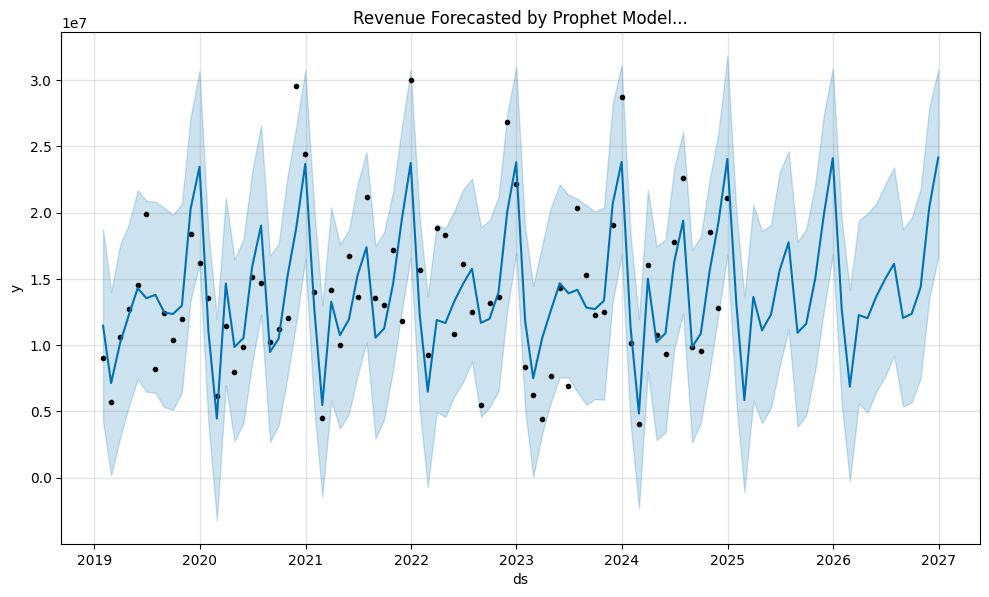

In [1583]:
#visualizing the predicted values....
revenue_Prophet_forecast_model.plot(revenue_future_df_forecast)
plt.title('Revenue Forecasted by Prophet Model...')
plt.show()

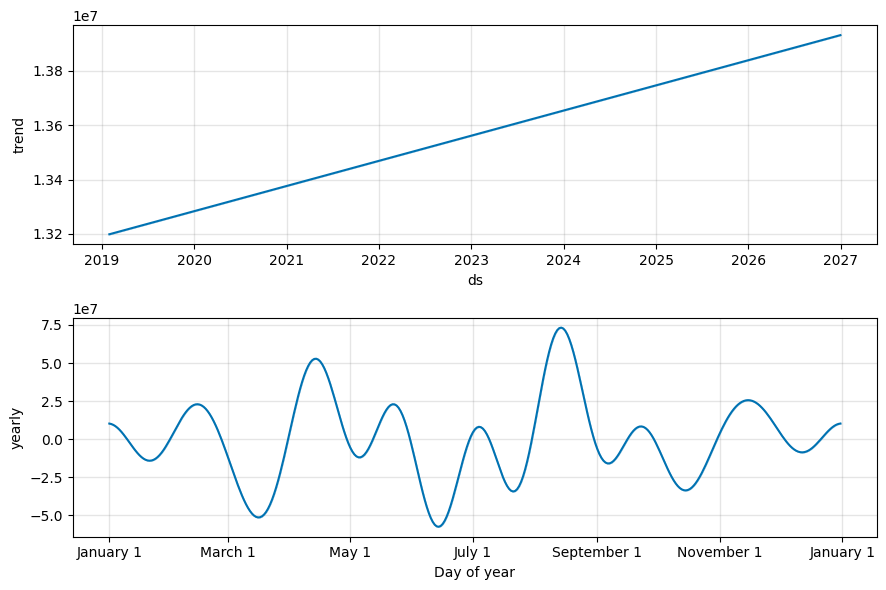

In [1584]:
revenue_Prophet_forecast_model.plot_components(revenue_future_df_forecast)
plt.show()

In [1585]:
total_revenue_month

#extracting actual revenue_values..
actual_revenue=total_revenue_month['y']

In [1586]:
revenue_future_forecast.iloc[71]

date                      2024-12-31 00:00:00
lower_bond                    16801645.948279
forecasted_revenue_KES         24058675.13955
upper_bond                    31876384.940564
Name: 71, dtype: object

In [1587]:
future_revenue_predictions=revenue_future_forecast['forecasted_revenue_KES'].iloc[:72]

In [1588]:
#Sending the revenue forecast dataframe to a file
revenue_future_forecast.to_csv('forecasted_revenue_data.csv')
revenue_future_forecast

,date,lower_bond,forecasted_revenue_KES,upper_bond
0,2019-01-31,4.232952e+06,1.147058e+07,1.876182e+07
1,2019-02-28,1.605992e+05,7.132303e+06,1.404446e+07
2,2019-03-31,2.975815e+06,1.016182e+07,1.756188e+07
3,2019-04-30,5.348440e+06,1.224531e+07,1.909876e+07
4,2019-05-31,7.430982e+06,1.430525e+07,2.168453e+07
...,...,...,...,...
91,2026-08-31,5.357264e+06,1.205403e+07,1.877157e+07
92,2026-09-30,5.679415e+06,1.236459e+07,1.959517e+07
93,2026-10-31,7.506818e+06,1.436734e+07,2.178807e+07
94,2026-11-30,1.352726e+07,2.042475e+07,2.796389e+07


In [1589]:
# Checking the accuracy error of the revenue predictions...
revenue_MAPE=mean_absolute_percentage_error(actual_revenue,future_revenue_predictions)
revenue_MAPE

0.23184635575241488

**The `accuracy error` of the `revenue monthly predictions` is ...`0.2318`; which is basically better than the before excel basic forecast; `0.42` Proceeding to the next Business
Problem: `Suppliers Delivery delays`**

**Calculating suppliers score from `ontime_deliveries / total_deliveries`**

In [1590]:
shipment_copy.head()

,shipment_id,supplier_id,sku_id,warehouse,ship_date,expected_delivery,actual_delivery,quantity_shipped,quantity_received,damage_reported,carrier,delay_days,delay_reason,extreme_delay_days
0,SHP0000001,Supplier_N,SKU0101,Cairo Depot,2020-11-03,2020-11-15,2020-11-17,1467,610,0,G4S Logistics,2,Unkown,0
1,SHP0000002,Supplier_S,SKU0078,Addis Ababa WH,2019-10-28,2019-11-10,2019-11-11,660,781,0,Kenya Courier,1,Vehicle breakdown,0
2,SHP0000003,Supplier_P,SKU0255,Lagos Facility,2024-01-21,2024-01-25,2024-02-01,1610,862,0,FedEx,7,Unkown,0
3,SHP0000004,Supplier_C,SKU0018,Cairo Depot,2021-06-01,2021-06-05,2021-06-10,1726,1703,0,Kenya Courier,5,Customs,0
4,SHP0000005,Supplier_M,SKU0188,Nairobi Warehouse,2021-02-10,2021-02-24,Unkown,97,1222,0,FedEx,3,Customs,0


**getting suppliers no delay supplies per month tally...**

In [1591]:
shipment_copy['ship_date']=pd.to_datetime(shipment_copy['ship_date'])
suppliers_no_delay_supply=shipment_copy[shipment_copy['delay_days']==0].groupby(['ship_date','supplier_id']).agg( {'shipment_id': 'count'} ).reset_index().sort_values(by='ship_date')

In [1592]:
suppliers_no_delay_supply

,ship_date,supplier_id,shipment_id
0,2019-01-01,Supplier_E,1
1,2019-01-01,Supplier_S,1
2,2019-01-02,Supplier_B,1
3,2019-01-02,Supplier_E,1
4,2019-01-02,Supplier_N,1
...,...,...,...
5327,2024-12-27,Supplier_P,1
5328,2024-12-28,Supplier_K,1
5329,2024-12-29,Supplier_H,1
5330,2024-12-30,Supplier_G,1


In [1593]:
suppliers_no_delay_supply=suppliers_no_delay_supply.set_index('ship_date')
suppliers_no_delay_supply=suppliers_no_delay_supply.groupby('supplier_id').resample('ME').agg({'shipment_id':'sum'}).reset_index()

suppliers_no_delay_supply['supplier_date']=suppliers_no_delay_supply['supplier_id'] + '_' + suppliers_no_delay_supply['ship_date'].astype(str)

In [1594]:
suppliers_no_delay_supply=suppliers_no_delay_supply.rename(columns={'shipment_id': 'on_time_deliveries'})
suppliers_no_delay_supply=suppliers_no_delay_supply.set_index('supplier_date')

**getting suppliers total supplies per month tally...**

In [1595]:
suppliers_total_supply=shipment_copy.groupby(['ship_date','supplier_id']).agg( {'shipment_id': 'count'} ).reset_index().sort_values(by='ship_date')

In [1596]:
suppliers_total_supply=suppliers_total_supply.set_index('ship_date').groupby('supplier_id').resample('ME').agg({'shipment_id': 'sum'}).reset_index()
suppliers_total_supply['supplier_date']=suppliers_total_supply['supplier_id'] + '_' + suppliers_total_supply['ship_date'].astype(str)

In [1597]:
suppliers_total_supply=suppliers_total_supply.rename(columns={'shipment_id': 'total_deliveries'})

suppliers_total_supply

,supplier_id,ship_date,total_deliveries,supplier_date
0,Supplier_A,2019-01-31,20,Supplier_A_2019-01-31
1,Supplier_A,2019-02-28,15,Supplier_A_2019-02-28
2,Supplier_A,2019-03-31,14,Supplier_A_2019-03-31
3,Supplier_A,2019-04-30,14,Supplier_A_2019-04-30
4,Supplier_A,2019-05-31,15,Supplier_A_2019-05-31
...,...,...,...,...
1435,Supplier_T,2024-08-31,15,Supplier_T_2024-08-31
1436,Supplier_T,2024-09-30,21,Supplier_T_2024-09-30
1437,Supplier_T,2024-10-31,15,Supplier_T_2024-10-31
1438,Supplier_T,2024-11-30,11,Supplier_T_2024-11-30


**Merging on-time deliveries to total_deliveries per supplier monthly data...**

In [1598]:
suppliers_total_supply['on_time_deliveries']=suppliers_total_supply['supplier_date'].map(suppliers_no_delay_supply['on_time_deliveries'] )

In [1599]:
#There are some suppliers who have no on_time_deliveries after discovering..hence inputing NaNs with 0 for that column...
suppliers_total_supply['on_time_deliveries']=suppliers_total_supply['on_time_deliveries'].fillna(0)


#getting suppliers_score....
suppliers_total_supply['supplier_score']=suppliers_total_supply['on_time_deliveries'] / suppliers_total_supply['total_deliveries']

suppliers_total_supply=suppliers_total_supply.sort_values(by='supplier_score',ascending=False)


suppliers_total_supply

,supplier_id,ship_date,total_deliveries,supplier_date,on_time_deliveries,supplier_score
1252,Supplier_R,2021-05-31,15,Supplier_R_2021-05-31,9.0,0.600000
576,Supplier_I,2019-01-31,12,Supplier_I_2019-01-31,7.0,0.583333
497,Supplier_G,2024-06-30,19,Supplier_G_2024-06-30,11.0,0.578947
822,Supplier_L,2021-07-31,14,Supplier_L_2021-07-31,8.0,0.571429
1071,Supplier_O,2024-04-30,16,Supplier_O_2024-04-30,9.0,0.562500
...,...,...,...,...,...,...
62,Supplier_A,2024-03-31,18,Supplier_A_2024-03-31,0.0,0.000000
59,Supplier_A,2023-12-31,8,Supplier_A_2023-12-31,0.0,0.000000
61,Supplier_A,2024-02-29,12,Supplier_A_2024-02-29,0.0,0.000000
1416,Supplier_T,2023-01-31,15,Supplier_T_2023-01-31,0.0,0.000000


**Investigating why `supplier_B and supplier_Q` have `NaN` on `on_time_deliveries`**

In [1600]:
shipment_copy[ (shipment_copy['ship_date']>'2024-12-01') & ( (shipment_copy['supplier_id']=='Supplier_B') ) ]

,shipment_id,supplier_id,sku_id,warehouse,ship_date,expected_delivery,actual_delivery,quantity_shipped,quantity_received,damage_reported,carrier,delay_days,delay_reason,extreme_delay_days
20,SHP0000021,Supplier_B,SKU0212,Nairobi Warehouse,2024-12-21,2024-12-27,2024-12-29,1382,337,0,FedEx,2,Unkown,0
777,SHP0000778,Supplier_B,SKU0283,Johannesburg DC,2024-12-20,2024-12-29,2025-01-04,1250,489,0,Kenya Courier,6,Vehicle breakdown,0
2367,SHP0002368,Supplier_B,SKU0039,Nairobi Warehouse,2024-12-04,2024-12-09,2024-12-10,206,351,1,DHL,1,Weather,0
3615,SHP0003616,Supplier_B,SKU0243,Johannesburg DC,2024-12-24,2025-01-04,2025-01-12,654,1559,0,G4S Logistics,8,Unkown,0
13103,SHP0013104,Supplier_B,SKU0036,Accra Hub,2024-12-25,2024-12-31,2025-01-08,843,587,0,FedEx,8,Unkown,0
17265,SHP0017266,Supplier_B,SKU0013,Nairobi Warehouse,2024-12-25,2024-12-31,2025-01-05,1716,1556,0,DHL,5,Supplier delay,0
23613,SHP0023614,Supplier_B,SKU0004,Addis Ababa WH,2024-12-20,2024-12-29,Unkown,955,1241,0,FedEx,10,Supplier delay,1


In [1601]:
shipment_copy[ (shipment_copy['ship_date']>'2024-12-01') & ( (shipment_copy['supplier_id']=='Supplier_Q') ) ]

,shipment_id,supplier_id,sku_id,warehouse,ship_date,expected_delivery,actual_delivery,quantity_shipped,quantity_received,damage_reported,carrier,delay_days,delay_reason,extreme_delay_days
857,SHP0000858,Supplier_Q,SKU0184,Johannesburg DC,2024-12-07,2024-12-15,2024-12-24,733,211,0,Aramex,9,Port congestion,1
1220,SHP0001221,Supplier_Q,SKU0182,Accra Hub,2024-12-17,2024-12-31,2025-01-06,682,1438,1,DHL,6,Unkown,0
1980,SHP0001981,Supplier_Q,SKU0013,Johannesburg DC,2024-12-16,2024-12-27,2024-12-31,836,867,0,UPS,4,Unkown,0
4519,SHP0004520,Supplier_Q,SKU0057,Cairo Depot,2024-12-06,2024-12-16,2024-12-22,1553,1316,0,Kenya Courier,6,Unkown,0
8111,SHP0008112,Supplier_Q,SKU0251,Accra Hub,2024-12-15,2024-12-22,2024-12-31,443,1343,0,UPS,9,Port congestion,1
9256,SHP0009257,Supplier_Q,SKU0227,Accra Hub,2024-12-27,2025-01-02,2025-01-09,683,554,0,G4S Logistics,7,Unkown,0
10832,SHP0010833,Supplier_Q,SKU0257,Cairo Depot,2024-12-04,2024-12-15,2024-12-20,226,1105,0,Kenya Courier,5,Customs,0
12515,SHP0012516,Supplier_Q,SKU0271,Nairobi Warehouse,2024-12-02,2024-12-06,2024-12-09,681,535,0,G4S Logistics,3,Port congestion,0
14429,SHP0014430,Supplier_Q,SKU0115,Accra Hub,2024-12-24,2024-12-30,2025-01-07,1872,1530,0,UPS,8,Unkown,0
15693,SHP0015694,Supplier_Q,SKU0071,Addis Ababa WH,2024-12-12,2024-12-23,2024-12-25,1061,787,0,Kenya Courier,2,Unkown,0


In [1602]:
suppliers_total_supply[suppliers_total_supply['ship_date'] == '2024-12-31'].tail()

,supplier_id,ship_date,total_deliveries,supplier_date,on_time_deliveries,supplier_score
1439,Supplier_T,2024-12-31,26,Supplier_T_2024-12-31,3.0,0.115385
71,Supplier_A,2024-12-31,19,Supplier_A_2024-12-31,2.0,0.105263
503,Supplier_G,2024-12-31,20,Supplier_G_2024-12-31,2.0,0.100000
1223,Supplier_Q,2024-12-31,16,Supplier_Q_2024-12-31,0.0,0.000000
143,Supplier_B,2024-12-31,8,Supplier_B_2024-12-31,0.0,0.000000


In [1603]:
suppliers_total_supply=suppliers_total_supply.drop(columns=['supplier_date'])

In [1604]:
#sending the suppliers score values to a file
suppliers_total_supply.to_csv('suppliers_monthly_score_performance_over_time.csv')

**`Delays issue resolved` since we now know which `suppliers are reliable for on_time_deliveries`...Proceeding to the next business issue...`Stock-outs`**

In [1605]:
inventory_copy.head()

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,skuId_warehouse_date,closing_stock_missmatch_flag
0,INV0000001,SKU0173,Nairobi_Warehouse,2024-07-27,616,160,59,20,697,168,288,27.4,0,2024-07-27_SKU0173_Nairobi_Warehouse,1
1,INV0000002,SKU0290,Nairobi_Warehouse,2023-01-05,700,296,264,3,729,81,488,52.8,0,2023-01-05_SKU0290_Nairobi_Warehouse,1
2,INV0000003,SKU0102,Lagos_Facility,2019-05-22,685,384,40,16,1013,162,189,NaN,0,2019-05-22_SKU0102_Lagos_Facility,1
3,INV0000004,SKU0045,Cairo_Depot,2023-05-05,922,224,265,19,862,57,110,7.7,0,2023-05-05_SKU0045_Cairo_Depot,1
4,INV0000005,SKU0105,Cairo_Depot,2021-03-28,310,203,9,3,501,95,451,13.2,0,2021-03-28_SKU0105_Cairo_Depot,1


In [1606]:
len(inventory_copy[inventory_copy['stockout_flag']==1])

1941

**There are `1941` records that have a `positive stockout_flag`**

In [1607]:
inventory_copy[inventory_copy['stockout_flag']==1].sample(5)

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,skuId_warehouse_date,closing_stock_missmatch_flag
9977,INV0009978,SKU0017,Cairo_Depot,2022-12-12,830,80,108,15,787,141,338,49.2,1,2022-12-12_SKU0017_Cairo_Depot,1
1140,INV0001141,SKU0254,Johannesburg_DC,2024-10-10,341,399,56,18,666,132,253,41.5,1,2024-10-10_SKU0254_Johannesburg_DC,1
19934,INV0019935,SKU0120,Johannesburg_DC,2024-02-19,701,59,46,15,699,102,200,31.7,1,2024-02-19_SKU0120_Johannesburg_DC,1
8457,INV0008458,SKU0076,Nairobi_Warehouse,2021-10-25,755,32,153,3,631,137,352,30.7,1,2021-10-25_SKU0076_Nairobi_Warehouse,1
14564,INV0014565,SKU0090,Addis_Ababa_WH,2021-03-09,79,172,245,16,-10,184,482,57.7,1,2021-03-09_SKU0090_Addis_Ababa_WH,1


In [1608]:
inventory_copy[inventory_copy['stockout_flag']==1].describe()

,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,closing_stock_missmatch_flag
count,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1817.000000,1941.0,1941.0
mean,498.013395,249.137558,151.068006,10.146832,585.936115,125.187532,298.625966,29.666924,1.0,1.0
std,288.923285,145.698227,87.134814,6.069832,332.448999,42.981330,114.726970,17.327159,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,-275.000000,50.000000,100.000000,0.000000,1.0,1.0
25%,249.000000,122.000000,74.000000,5.000000,340.000000,88.000000,198.000000,14.700000,1.0,1.0
50%,506.000000,247.000000,153.000000,10.000000,584.000000,127.000000,303.000000,29.400000,1.0,1.0
75%,744.000000,373.000000,226.000000,15.000000,836.000000,163.000000,396.000000,44.800000,1.0,1.0
max,1000.000000,499.000000,300.000000,20.000000,1409.000000,200.000000,500.000000,60.000000,1.0,1.0


In [1609]:
inventory_copy[inventory_copy['stockout_flag']==0].describe()

,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,closing_stock_missmatch_flag
count,38059.000000,38059.000000,38059.000000,38059.000000,38059.000000,38059.000000,38059.000000,35392.000000,38059.0,38059.000000
mean,501.201766,250.843638,149.672666,9.977587,592.395150,125.374340,299.365354,29.897985,0.0,0.999238
std,289.774129,144.400533,87.233319,6.050708,335.251166,43.582523,115.370574,17.358863,0.0,0.027594
min,0.000000,0.000000,0.000000,0.000000,-294.000000,50.000000,100.000000,0.000000,0.0,0.000000
25%,249.000000,126.000000,74.000000,5.000000,338.000000,88.000000,199.000000,14.800000,0.0,1.000000
50%,503.000000,251.000000,149.000000,10.000000,594.000000,126.000000,300.000000,29.700000,0.0,1.000000
75%,754.000000,375.000000,226.000000,15.000000,846.000000,163.000000,399.000000,44.900000,0.0,1.000000
max,1000.000000,500.000000,300.000000,20.000000,1481.000000,200.000000,500.000000,60.000000,0.0,1.000000


**Re-computing `stockout_flag` column `if` `closing_stock <=0`**

In [1610]:
inventory_copy['stockout_flag']=np.where(inventory_copy['closing_stock'] <=0 , 1 , 0)

In [1611]:
len(inventory_copy[inventory_copy['stockout_flag']==1])

1332

In [1612]:
len(inventory_copy[inventory_copy['stockout_flag']==0])

38668

In [1613]:
inventory_copy[inventory_copy['stockout_flag']==1].sample(5)

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,skuId_warehouse_date,closing_stock_missmatch_flag
38356,INV0038357,SKU0272,Lagos_Facility,2020-05-28,60,60,174,5,-59,184,230,42.7,1,2020-05-28_SKU0272_Lagos_Facility,1
20418,INV0020419,SKU0048,Johannesburg_DC,2024-12-24,206,66,281,15,-24,61,130,32.2,1,2024-12-24_SKU0048_Johannesburg_DC,1
19445,INV0019446,SKU0093,Lagos_Facility,2021-03-26,58,119,257,20,-100,91,327,50.4,1,2021-03-26_SKU0093_Lagos_Facility,1
12591,INV0012592,SKU0211,Accra_Hub,2021-08-06,45,148,209,12,-28,149,478,25.3,1,2021-08-06_SKU0211_Accra_Hub,1
13985,INV0013986,SKU0025,Johannesburg_DC,2023-02-21,167,39,209,9,-12,190,366,37.6,1,2023-02-21_SKU0025_Johannesburg_DC,1


**Re-computing `days_of_stock` column `(closing_stock / sold_qty)`**

In [1614]:
inventory_copy['days_of_stock']=np.where( inventory_copy['closing_stock']> 0, (inventory_copy['closing_stock'] / inventory_copy['sold_qty']) ,0 )

In [1615]:
inventory_copy['days_of_stock']=np.round(inventory_copy['days_of_stock'])

In [1616]:
inventory_copy[inventory_copy['stockout_flag']==1].sample(5)

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,skuId_warehouse_date,closing_stock_missmatch_flag
31466,INV0031467,SKU0083,Johannesburg_DC,2019-10-04,93,141,291,6,-63,58,293,0.0,1,2019-10-04_SKU0083_Johannesburg_DC,1
28770,INV0028771,SKU0250,Addis_Ababa_WH,2021-02-24,27,216,297,9,-63,101,355,0.0,1,2021-02-24_SKU0250_Addis_Ababa_WH,1
7191,INV0007192,SKU0032,Lagos_Facility,2019-06-22,22,117,187,7,-55,131,470,0.0,1,2019-06-22_SKU0032_Lagos_Facility,1
8500,INV0008501,SKU0097,Johannesburg_DC,2022-07-13,83,94,291,20,-134,76,408,0.0,1,2022-07-13_SKU0097_Johannesburg_DC,1
22909,INV0022910,SKU0141,Cairo_Depot,2021-03-07,74,145,290,11,-82,137,272,0.0,1,2021-03-07_SKU0141_Cairo_Depot,1


In [1617]:
inventory_copy.head()

,log_id,sku_id,warehouse,snapshot_date,opening_stock,received_qty,sold_qty,damaged_qty,closing_stock,reorder_point,reorder_qty,days_of_stock,stockout_flag,skuId_warehouse_date,closing_stock_missmatch_flag
0,INV0000001,SKU0173,Nairobi_Warehouse,2024-07-27,616,160,59,20,697,168,288,12.0,0,2024-07-27_SKU0173_Nairobi_Warehouse,1
1,INV0000002,SKU0290,Nairobi_Warehouse,2023-01-05,700,296,264,3,729,81,488,3.0,0,2023-01-05_SKU0290_Nairobi_Warehouse,1
2,INV0000003,SKU0102,Lagos_Facility,2019-05-22,685,384,40,16,1013,162,189,25.0,0,2019-05-22_SKU0102_Lagos_Facility,1
3,INV0000004,SKU0045,Cairo_Depot,2023-05-05,922,224,265,19,862,57,110,3.0,0,2023-05-05_SKU0045_Cairo_Depot,1
4,INV0000005,SKU0105,Cairo_Depot,2021-03-28,310,203,9,3,501,95,451,56.0,0,2021-03-28_SKU0105_Cairo_Depot,1


In [1618]:
inventory_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   log_id                        40000 non-null  object 
 1   sku_id                        40000 non-null  object 
 2   warehouse                     40000 non-null  object 
 3   snapshot_date                 40000 non-null  object 
 4   opening_stock                 40000 non-null  int64  
 5   received_qty                  40000 non-null  int64  
 6   sold_qty                      40000 non-null  int64  
 7   damaged_qty                   40000 non-null  int64  
 8   closing_stock                 40000 non-null  int64  
 9   reorder_point                 40000 non-null  int64  
 10  reorder_qty                   40000 non-null  int64  
 11  days_of_stock                 40000 non-null  float64
 12  stockout_flag                 40000 non-null  int64  
 13  s

**The missing values of `days_of_stock` has been resolved! No missing values in `inventory_data`**